# Knee Exo — batch GT vs logged model

Batch comparison for all `*_knee_*_exo_on` telemetry trials.

- **Sync**: GPIO falling-edge alignment (telemetry vs mocap jet)
- **GT**: Vicon ID/mass − `cmd_R`/mass, zero-phase 6 Hz LPF
- **Model**: logged `model_out_nmpkg_raw` from telemetry NPZ (no re-inference)
- **Metrics / plots**: RMSE and R² after removing first/last 10 s post-sync (`TRIM_START_SEC` / `TRIM_END_SEC`)


In [29]:
import io
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import butter, sosfilt, sosfiltfilt

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
TELEMETRY_ROOT = PROJECT_ROOT

EXO_KIND = 'knee-exo'
JOINT = 'knee_angle_r'
JOINT_LABEL = 'Knee R'
MOMENT_COL = 'knee_angle_r_moment'
MOCAP_FS_HZ = 1000.0
LPF_CUTOFF_HZ, LPF_ORDER = 6.0, 4
GT_LPF_MODE = 'zero_phase'
TELEMETRY_PATTERN = '*_knee_*_exo_on.npz'
GT_METRIC_LABEL = 'GT (ID/mass − cmd_R/mass) vs logged model'
PAPER_SUBDIR = 'knee_exo'

SUBJECT_TOKEN_TO_DIR = {
    'ab01_jinwoo': 'AB01_Jinwoo', 'ab02_oscar': 'AB02_Oscar', 'ab03_ilseung': 'AB03_Ilseung',
    'ab04_changseob': 'AB04_Changseob', 'ab05_maria': 'AB05_Maria', 'ab06_jimin': 'AB06_Jimin',
    'ab07_amy': 'AB07_Amy', 'ab08_seokhyun': 'AB08_Seokhyun',
}
SUBJECT_MASS_KG = {
    'ab01_jinwoo': 88.0, 'ab02_oscar': 71.1, 'ab03_ilseung': 84.4, 'ab04_changseob': 74.0,
    'ab05_maria': 55.0, 'ab06_jimin': 82.6, 'ab07_amy': 51.3, 'ab08_seokhyun': 71.9,
}

CACHE_DIR = PROJECT_ROOT / 'analysis' / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / 'compare_processed_knee_exo_id.npz'
METRICS_CSV_PATH = CACHE_DIR / 'compare_processed_knee_exo_id_metrics.csv'

LOAD_FROM_CACHE = False
SAVE_TO_CACHE = True

# Post-sync trim applied to metrics and plots (set ends to 0.0 to disable).
TRIM_START_SEC = 10.0
TRIM_END_SEC = 10.0

# Set to None to include all subjects.
EXCLUDE_SUBJECTS = None

print(f'Exo: {EXO_KIND} | joint: {JOINT_LABEL}')
print(f'Processed root: {PROCESSED_ROOT}')
print(f'Cache: {CACHE_PATH}')
print(f'LOAD_FROM_CACHE={LOAD_FROM_CACHE} | SAVE_TO_CACHE={SAVE_TO_CACHE}')
print(f'EXCLUDE_SUBJECTS={EXCLUDE_SUBJECTS}')


Exo: knee-exo | joint: Knee R
Processed root: /media/metamobility3/Samsung_T52/Results/processed
Cache: /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_knee_exo_id.npz
LOAD_FROM_CACHE=False | SAVE_TO_CACHE=True
EXCLUDE_SUBJECTS=None


In [30]:
def butter_lpf(x, fs_hz, cutoff_hz, order, mode='zero_phase'):
    arr = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * float(fs_hz)
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(arr) < 4:
        return arr
    sos = butter(int(order), float(cutoff_hz) / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, arr) if mode == 'zero_phase' else sosfilt(sos, arr)


def lpf_nan(x, fs_hz, cutoff_hz, order, mode):
    arr = np.asarray(x, dtype=np.float64).copy()
    finite = np.isfinite(arr)
    if finite.sum() < max(3, order + 1):
        return arr
    if finite.all():
        return butter_lpf(arr, fs_hz, cutoff_hz, order, mode)
    idx = np.arange(arr.size, dtype=np.float64)
    filled = np.interp(idx, idx[finite], arr[finite])
    out = butter_lpf(filled, fs_hz, cutoff_hz, order, mode)
    out[~finite] = np.nan
    return out


def rmse_r2(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan, np.nan
    e = y_pred[m] - y_true[m]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    ss_res = float(np.sum(e ** 2))
    ss_tot = float(np.sum((y_true[m] - np.mean(y_true[m])) ** 2))
    return rmse, float(1.0 - ss_res / (ss_tot + 1e-12))


def read_sto(path: Path):
    with open(path) as f:
        lines = f.readlines()
    end_idx = next(i for i, l in enumerate(lines) if l.strip().lower() == 'endheader')
    cols = lines[end_idx + 1].strip().split()
    data = np.loadtxt(io.StringIO(''.join(lines[end_idx + 2:])))
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return cols, data


def infer_fs_hz(time_s, default_fs=100.0):
    if time_s is None or len(time_s) < 3:
        return float(default_fs)
    dt = np.diff(np.asarray(time_s, dtype=np.float64))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(1.0 / np.median(dt)) if dt.size else float(default_fs)


def _subject_token(stem: str) -> str:
    return '_'.join(stem.lower().split('_')[:2])


def subject_dir_from_stem(stem: str) -> Path:
    token = _subject_token(stem)
    name = SUBJECT_TOKEN_TO_DIR[token]
    p = PROCESSED_ROOT / name
    if not p.is_dir():
        raise FileNotFoundError(p)
    return p


def trial_cond_speed(stem: str) -> Tuple[str, str]:
    parts = stem.lower().split('_')
    return parts[4].upper(), parts[3]


def trial_meta_from_stem(stem: str) -> Dict[str, object]:
    token = _subject_token(stem)
    subject = SUBJECT_TOKEN_TO_DIR[token]
    cond, speed = trial_cond_speed(stem)
    condition = f'{cond}_{speed}'
    speed_mps = float(speed.replace('mps', '').replace('p', '.'))
    return {
        'subject': subject,
        'task': cond,
        'speed': speed,
        'condition': condition,
        'speed_mps': speed_mps,
        'trial_key': f'{subject}::{condition}',
    }


def parse_mocap_csv(path: Path, fs: float = MOCAP_FS_HZ):
    df = pd.read_csv(path, skiprows=[0, 1, 2, 4], header=0, low_memory=False, on_bad_lines='skip')
    df = df[pd.to_numeric(df['Frame'], errors='coerce').notna()].copy()
    df['jet'] = pd.to_numeric(df['jet'], errors='coerce')
    df = df.dropna(subset=['jet']).reset_index(drop=True)
    return np.arange(len(df)) / fs, df['jet'].to_numpy(dtype=float)


def normalize_gpio(gpio: np.ndarray) -> np.ndarray:
    arr = np.asarray(gpio, dtype=np.float64)
    g_range = arr.max() - arr.min()
    return arr if g_range <= 0 else (arr - arr.min()) / g_range


def first_falling_edge(signal: np.ndarray, threshold: float = 0.5) -> Optional[int]:
    above = np.asarray(signal, dtype=np.float64) > threshold
    for i in range(1, len(above)):
        if above[i - 1] and not above[i]:
            return i
    return None


def extract_gpio(npz) -> Tuple[np.ndarray, str]:
    for k in ('gpio_output', 'GPIO', 'gpio', 'trigger'):
        if k in npz.files:
            return np.asarray(npz[k], dtype=np.float64), k
    raise KeyError('No GPIO key in npz')


def gpio_offset_s(t_exo, g_exo, t_mocap, g_mocap):
    idx_exo = first_falling_edge(g_exo)
    idx_mocap = first_falling_edge(normalize_gpio(g_mocap))
    if idx_exo is None or idx_mocap is None:
        return None, idx_exo, idx_mocap
    return float(t_mocap[idx_mocap] - t_exo[idx_exo]), idx_exo, idx_mocap


def resolve_trial_paths(trial_stem: str) -> Dict[str, Path]:
    cond, speed = trial_cond_speed(trial_stem)
    subj_dir = subject_dir_from_stem(trial_stem)
    return {
        'npz': TELEMETRY_ROOT / f'{trial_stem}.npz',
        'mocap': subj_dir / EXO_KIND / 'mocap' / f'{cond}_{speed}.csv',
        'id': subj_dir / EXO_KIND / 'id' / f'{cond}_{speed}_id.sto',
        'cond': cond,
        'speed': speed,
        'subject_dir': subj_dir,
    }


def load_gpio_sync_data(trial_stem: str) -> Dict:
    paths = resolve_trial_paths(trial_stem)
    for key in ('npz', 'mocap', 'id'):
        if not paths[key].exists():
            raise FileNotFoundError(f'Missing {key}: {paths[key]}')

    d = np.load(str(paths['npz']), allow_pickle=True)
    gpio, gpio_key = extract_gpio(d)
    t_raw = np.asarray(d['time'], dtype=np.float64) if 'time' in d.files else np.arange(len(gpio), dtype=np.float64)
    n = min(len(t_raw), len(gpio))
    t_raw, gpio = t_raw[:n], gpio[:n]

    t_mocap, gpio_mocap = parse_mocap_csv(paths['mocap'])
    offset_s, idx_exo, idx_mocap = gpio_offset_s(t_raw, gpio, t_mocap, gpio_mocap)

    return {
        'trial': trial_stem,
        'sync_method': 'gpio_falling_edge',
        'paths': paths,
        'npz': d,
        'gpio_key': gpio_key,
        'offset_s': offset_s,
        'idx_exo': idx_exo,
        'idx_mocap': idx_mocap,
        'fs_npz_hz': infer_fs_hz(t_raw),
        'fs_mocap_hz': infer_fs_hz(t_mocap, default_fs=MOCAP_FS_HZ),
        't_npz': t_raw,
        'gpio_npz': gpio,
        't_mocap': t_mocap,
        'gpio_mocap_raw': gpio_mocap,
        'gpio_mocap_norm': normalize_gpio(gpio_mocap),
        't_npz_aligned': t_raw + float(offset_s) if offset_s is not None else t_raw.copy(),
    }


def is_excluded_subject(subject_name: str) -> bool:
    return EXCLUDE_SUBJECTS is not None and subject_name in EXCLUDE_SUBJECTS


def valid_telemetry_stem(stem: str) -> bool:
    token = _subject_token(stem)
    if token not in SUBJECT_TOKEN_TO_DIR:
        return False
    return not is_excluded_subject(SUBJECT_TOKEN_TO_DIR[token])


def analysis_trim_mask(
    t: np.ndarray,
    trim_start_s: float = TRIM_START_SEC,
    trim_end_s: float = TRIM_END_SEC,
) -> np.ndarray:
    """Post-sync mask: drop first/last N seconds of each trial."""
    t_rel = np.asarray(t, dtype=np.float64) - np.nanmin(t)
    t_end = float(np.nanmax(t_rel))
    return (t_rel >= float(trim_start_s)) & (t_rel <= t_end - float(trim_end_s))


def save_processed_exo_cache(trial_data: Dict[str, Dict], path: Path = CACHE_PATH) -> None:
    if not trial_data:
        raise RuntimeError('TRIAL_DATA is empty')
    payload = {'trial_keys': np.array(sorted(trial_data.keys()), dtype=object)}
    for trial_key, d in trial_data.items():
        p = str(trial_key)
        payload[f'{p}__t'] = np.asarray(d['t'], dtype=np.float64)
        payload[f'{p}__gt_nmpkg'] = np.asarray(d['gt_nmpkg'], dtype=np.float64)
        payload[f'{p}__model_out_nmpkg_raw'] = np.asarray(d['model_out_nmpkg_raw'], dtype=np.float64)
        payload[f'{p}__meta'] = np.array([
            d['joint'], d['moment_col'], d['mass_kg'], d['offset_s'],
            d['applied_key'], d['gpio_key'], d['model_out_key'], d['trial_key'],
        ], dtype=object)
    np.savez_compressed(str(path), **payload)
    print(f'Saved {len(trial_data)} trials → {path}')


def load_processed_exo_cache(path: Path = CACHE_PATH) -> Dict[str, Dict]:
    if not path.exists():
        raise FileNotFoundError(f'Cache not found: {path}')
    data = np.load(str(path), allow_pickle=True)
    trial_data: Dict[str, Dict] = {}
    for trial_key in data['trial_keys']:
        p = str(trial_key)
        meta = data[f'{p}__meta']
        trial_data[p] = {
            'trial': p,
            'joint': str(meta[0]),
            'moment_col': str(meta[1]),
            'mass_kg': float(meta[2]),
            'offset_s': float(meta[3]),
            'applied_key': str(meta[4]),
            'gpio_key': str(meta[5]),
            'model_out_key': str(meta[6]),
            'trial_key': str(meta[7]),
            't': np.asarray(data[f'{p}__t'], dtype=np.float64),
            'gt_nmpkg': np.asarray(data[f'{p}__gt_nmpkg'], dtype=np.float64),
            'model_out_nmpkg_raw': np.asarray(data[f'{p}__model_out_nmpkg_raw'], dtype=np.float64),
        }
    print(f'Loaded {len(trial_data)} trials from {path}')
    return trial_data

def extract_model_out_nmpkg_raw(npz) -> Tuple[np.ndarray, str]:
    for k in ('model_out_nmpkg_raw', 'model_out_nmpkg'):
        if k in npz.files:
            return np.asarray(npz[k], dtype=np.float64), k
    raise KeyError(f'No model output key; available: {sorted(npz.files)}')


def extract_applied_cmd_nm(npz) -> Tuple[np.ndarray, str]:
    for k in ('cmd_R', 'cmd_L'):
        if k in npz.files:
            return np.asarray(npz[k], dtype=np.float64), k
    raise KeyError(f'No cmd_R/cmd_L; available: {sorted(npz.files)}')


def load_moment_waveforms(trial_stem: str, sync: Dict) -> Dict:
    """GPIO-synced GT vs logged model_out_nmpkg_raw."""
    paths = sync['paths']
    mass = SUBJECT_MASS_KG[_subject_token(trial_stem)]
    d = sync['npz']

    applied_nm, applied_key = extract_applied_cmd_nm(d)
    model_out_raw, model_out_key = extract_model_out_nmpkg_raw(d)

    n = min(len(sync['t_npz']), len(applied_nm), len(model_out_raw))
    t_aligned = sync['t_npz_aligned'][:n].astype(np.float64)
    applied_nm = applied_nm[:n]
    model_out_nmpkg_raw = np.asarray(model_out_raw[:n], dtype=np.float64)
    fs_hz = infer_fs_hz(sync['t_npz'][:n])

    cols, id_data = read_sto(paths['id'])
    t_id = id_data[:, cols.index('time')]
    id_moment_nm = id_data[:, cols.index(MOMENT_COL)]

    id_nm_raw = np.interp(t_aligned, t_id, id_moment_nm, left=np.nan, right=np.nan)
    id_nmpkg_raw = id_nm_raw / mass
    applied_nmpkg_raw = applied_nm / mass

    net_raw_nmpkg = id_nmpkg_raw - applied_nmpkg_raw
    gt_nmpkg = lpf_nan(net_raw_nmpkg, fs_hz, LPF_CUTOFF_HZ, LPF_ORDER, GT_LPF_MODE)

    meta = trial_meta_from_stem(trial_stem)
    return {
        'trial': trial_stem,
        'trial_key': meta['trial_key'],
        'joint': JOINT,
        't': t_aligned,
        'gt_nmpkg': gt_nmpkg,
        'model_out_nmpkg_raw': model_out_nmpkg_raw,
        'applied_key': applied_key,
        'model_out_key': model_out_key,
        'mass_kg': mass,
        'moment_col': MOMENT_COL,
        'fs_hz': fs_hz,
    }


def process_trial_waveforms(trial_stem: str):
    try:
        sync = load_gpio_sync_data(trial_stem)
    except FileNotFoundError as exc:
        return None, str(exc)
    if sync['offset_s'] is None:
        return None, 'no GPIO falling edge'
    wave = load_moment_waveforms(trial_stem, sync)
    wave['offset_s'] = float(sync['offset_s'])
    wave['gpio_key'] = sync['gpio_key']
    return wave, None

print('Helpers ready.')


Helpers ready.


## 1. Batch processing (GPIO sync)

In [31]:
CANDIDATES = sorted(
    p for p in TELEMETRY_ROOT.glob(TELEMETRY_PATTERN)
    if valid_telemetry_stem(p.stem)
)
print(f'Found {len(CANDIDATES)} telemetry files')

WARNINGS: List[str] = []
TRIAL_DATA: Dict[str, Dict] = {}

if LOAD_FROM_CACHE:
    TRIAL_DATA = load_processed_exo_cache(CACHE_PATH)
else:
    for npz_path in CANDIDATES:
        stem = npz_path.stem
        try:
            wave, err = process_trial_waveforms(stem)
            if wave is None:
                WARNINGS.append(f'[WARN] {stem}: {err}')
                print(f'SKIP {stem}: {err}')
                continue
            TRIAL_DATA[stem] = wave
            print(f"OK  {stem} | offset={wave['offset_s']:+.3f}s | n={len(wave['t'])}")
        except Exception as exc:
            WARNINGS.append(f'[WARN] {stem}: {exc}')
            print(f'FAIL {stem}: {exc}')

    if SAVE_TO_CACHE and TRIAL_DATA:
        save_processed_exo_cache(TRIAL_DATA)

def filter_excluded_trials(trial_data: Dict[str, Dict]) -> Dict[str, Dict]:
    if EXCLUDE_SUBJECTS is None:
        return trial_data
    kept = {
        stem: wave for stem, wave in trial_data.items()
        if not is_excluded_subject(SUBJECT_TOKEN_TO_DIR[_subject_token(stem)])
    }
    dropped = len(trial_data) - len(kept)
    if dropped:
        print(f'Excluded subjects {sorted(EXCLUDE_SUBJECTS)} → dropped {dropped} trial(s)')
    return kept


TRIAL_DATA = filter_excluded_trials(TRIAL_DATA)

for w in WARNINGS:
    print(w)
print(f'\nLoaded {len(TRIAL_DATA)} trials')


Found 16 telemetry files
OK  ab01_jinwoo_knee_0p8mps_ra_exo_on | offset=-0.236s | n=8000
OK  ab01_jinwoo_knee_0p8mps_rd_exo_on | offset=-0.159s | n=8000
OK  ab02_oscar_knee_0p8mps_ra_exo_on | offset=-0.234s | n=8000
OK  ab02_oscar_knee_0p8mps_rd_exo_on | offset=-0.239s | n=8000
OK  ab03_ilseung_knee_0p8mps_ra_exo_on | offset=-0.180s | n=8000
OK  ab03_ilseung_knee_0p8mps_rd_exo_on | offset=-0.196s | n=8000
OK  ab04_changseob_knee_0p8mps_ra_exo_on | offset=-0.213s | n=8000
OK  ab04_changseob_knee_0p8mps_rd_exo_on | offset=-0.230s | n=8000
OK  ab05_maria_knee_0p8mps_ra_exo_on | offset=-0.179s | n=8000
OK  ab05_maria_knee_0p8mps_rd_exo_on | offset=-0.136s | n=8000
OK  ab06_jimin_knee_0p8mps_ra_exo_on | offset=-0.237s | n=8000
OK  ab06_jimin_knee_0p8mps_rd_exo_on | offset=-0.230s | n=8000
SKIP ab07_amy_knee_0p8mps_ra_exo_on: Missing id: /media/metamobility3/Samsung_T52/Results/processed/AB07_Amy/knee-exo/id/RA_0p8mps_id.sto
SKIP ab07_amy_knee_0p8mps_rd_exo_on: Missing id: /media/metamobilit

## 2. Metrics summary

In [32]:
if not TRIAL_DATA:
    raise RuntimeError('No trials loaded.')

metrics_rows = []
for stem, wave in sorted(TRIAL_DATA.items()):
    meta = trial_meta_from_stem(stem)
    m = analysis_trim_mask(wave['t'])
    rmse, r2 = rmse_r2(wave['gt_nmpkg'][m], wave['model_out_nmpkg_raw'][m])
    metrics_rows.append({
        'trial': stem,
        'trial_key': meta['trial_key'],
        'subject': meta['subject'],
        'task': meta['task'],
        'condition': meta['condition'],
        'rmse_nmpkg': rmse,
        'r2_nmpkg': r2,
        'offset_s': wave['offset_s'],
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(METRICS_CSV_PATH, index=False)
print(f'Saved metrics → {METRICS_CSV_PATH}')
display(metrics_df)
if metrics_df['rmse_nmpkg'].notna().any():
    print(
        f"Overall: RMSE={metrics_df['rmse_nmpkg'].mean():.4f} N·m/kg | "
        f"R²={metrics_df['r2_nmpkg'].mean():.4f}"
    )


Saved metrics → /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_knee_exo_id_metrics.csv


,trial,trial_key,subject,task,condition,rmse_nmpkg,r2_nmpkg,offset_s
0,ab01_jinwoo_knee_0p8mps_ra_exo_on,AB01_Jinwoo::RA_0p8mps,AB01_Jinwoo,RA,RA_0p8mps,0.202599,0.647440,-0.236059
1,ab01_jinwoo_knee_0p8mps_rd_exo_on,AB01_Jinwoo::RD_0p8mps,AB01_Jinwoo,RD,RD_0p8mps,0.357023,-0.250712,-0.159030
2,ab02_oscar_knee_0p8mps_ra_exo_on,AB02_Oscar::RA_0p8mps,AB02_Oscar,RA,RA_0p8mps,0.294758,0.281126,-0.234045
3,ab02_oscar_knee_0p8mps_rd_exo_on,AB02_Oscar::RD_0p8mps,AB02_Oscar,RD,RD_0p8mps,0.638611,-0.067564,-0.239053
4,ab03_ilseung_knee_0p8mps_ra_exo_on,AB03_Ilseung::RA_0p8mps,AB03_Ilseung,RA,RA_0p8mps,0.219304,0.578530,-0.180057
5,ab03_ilseung_knee_0p8mps_rd_exo_on,AB03_Ilseung::RD_0p8mps,AB03_Ilseung,RD,RD_0p8mps,0.249835,0.383583,-0.196053
6,ab04_changseob_knee_0p8mps_ra_exo_on,AB04_Changseob::RA_0p8mps,AB04_Changseob,RA,RA_0p8mps,0.175018,0.627131,-0.213057
7,ab04_changseob_knee_0p8mps_rd_exo_on,AB04_Changseob::RD_0p8mps,AB04_Changseob,RD,RD_0p8mps,0.192082,0.683597,-0.230038
8,ab05_maria_knee_0p8mps_ra_exo_on,AB05_Maria::RA_0p8mps,AB05_Maria,RA,RA_0p8mps,0.279019,0.486957,-0.179078
9,ab05_maria_knee_0p8mps_rd_exo_on,AB05_Maria::RD_0p8mps,AB05_Maria,RD,RD_0p8mps,0.880282,-0.254020,-0.136066


Overall: RMSE=0.3162 N·m/kg | R²=0.2741


## 3. Interactive QC

In [33]:
GPIO_PALETTE = {'mocap': '#90A4AE', 'telemetry': '#FF9800'}

def draw_gpio_sync(sync: Dict, window_s: float = 4.0) -> None:
    t_edge_mocap = float(sync['t_mocap'][sync['idx_mocap']])
    t_edge_npz = float(sync['t_npz'][sync['idx_exo']])
    t0, t1 = t_edge_mocap - 0.5, t_edge_mocap + window_s
    fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
    m_npz = (sync['t_npz'] >= t_edge_npz - 0.5) & (sync['t_npz'] <= t_edge_npz + window_s)
    m_mocap = (sync['t_mocap'] >= t0) & (sync['t_mocap'] <= t1)
    axs[0].plot(sync['t_npz'][m_npz], sync['gpio_npz'][m_npz], color=GPIO_PALETTE['telemetry'], lw=1.4, ls='--', label=f"Telemetry ({sync['gpio_key']})")
    axs[0].plot(sync['t_mocap'][m_mocap], sync['gpio_mocap_norm'][m_mocap], color=GPIO_PALETTE['mocap'], lw=1.2, label='Mocap jet (norm)')
    axs[0].axvline(t_edge_npz, color=GPIO_PALETTE['telemetry'], ls=':')
    axs[0].axvline(t_edge_mocap, color=GPIO_PALETTE['mocap'], ls=':')
    axs[0].set_ylabel('Amplitude (a.u.)'); axs[0].set_title('Before sync'); axs[0].legend(); axs[0].grid(alpha=0.25)
    m_a_npz = (sync['t_npz_aligned'] >= t0) & (sync['t_npz_aligned'] <= t1)
    axs[1].plot(sync['t_mocap'][m_mocap], sync['gpio_mocap_norm'][m_mocap], color=GPIO_PALETTE['mocap'], lw=1.2, label='Mocap jet (norm)')
    axs[1].plot(sync['t_npz_aligned'][m_a_npz], sync['gpio_npz'][m_a_npz], color=GPIO_PALETTE['telemetry'], lw=1.4, ls='--', label='Telemetry shifted')
    axs[1].axvline(t_edge_mocap, color='black', ls=':')
    axs[1].set_xlabel('Mocap time (s)'); axs[1].set_ylabel('Amplitude (a.u.)')
    axs[1].set_title(f'After sync | offset {sync["offset_s"]:+.4f} s')
    axs[1].legend(); axs[1].grid(alpha=0.25)
    fig.suptitle(f"{sync['trial']} | GPIO sync", y=1.01)
    fig.tight_layout(); plt.show()

gpio_trial_dd = widgets.Dropdown(options=sorted(TRIAL_DATA), description='Trial:')
gpio_window = widgets.FloatSlider(value=4.0, min=1.0, max=15.0, step=0.5, description='Window (s):')
gpio_out = widgets.Output()

def _draw_gpio(*_):
    with gpio_out:
        gpio_out.clear_output(wait=True)
        draw_gpio_sync(load_gpio_sync_data(gpio_trial_dd.value), gpio_window.value)

gpio_trial_dd.observe(_draw_gpio, names='value')
gpio_window.observe(_draw_gpio, names='value')
display(widgets.VBox([widgets.HBox([gpio_trial_dd, gpio_window]), gpio_out]))
_draw_gpio()


In [34]:
res_out = widgets.Output()
res_trial_dd = widgets.Dropdown(options=sorted(TRIAL_DATA), description='Trial:')
res_slider = widgets.FloatRangeSlider(description='Time (s):', continuous_update=False, readout_format='.2f', layout=widgets.Layout(width='760px'))

def draw_gt_residual(wave: Dict, t_window: Tuple[float, float]) -> None:
    t_rel = wave['t'] - np.nanmin(wave['t'])
    t0, t1 = t_window
    gt = wave['gt_nmpkg']
    model = wave['model_out_nmpkg_raw']
    m = analysis_trim_mask(wave['t']) & (t_rel >= t0) & (t_rel <= t1) & np.isfinite(gt) & np.isfinite(model)
    rmse, r2 = rmse_r2(gt[m], model[m])
    fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axs[0].plot(t_rel[m], gt[m], color='#1e88e5', lw=2.0, label='GT')
    axs[0].plot(t_rel[m], model[m], color='#e53935', lw=1.6, ls='--', label='Logged model')
    axs[0].set_ylabel('N·m/kg')
    axs[0].set_title(f"RMSE={rmse:.4f} | R²={r2:.4f} | offset={wave['offset_s']:+.3f}s")
    axs[0].legend(); axs[0].grid(alpha=0.25)
    axs[1].plot(t_rel[m], (model - gt)[m], color='#9c27b0', lw=1.4, label='Model − GT')
    axs[1].axhline(0, color='black', ls=':')
    axs[1].set_ylabel('Residual (N·m/kg)'); axs[1].set_xlabel('Time (s)')
    axs[1].legend(); axs[1].grid(alpha=0.25)
    fig.tight_layout()
    with res_out:
        res_out.clear_output(wait=True); plt.show()

def _init_res_slider(trial_key: str) -> None:
    wave = TRIAL_DATA[trial_key]
    t_rel = wave['t'] - np.nanmin(wave['t'])
    m = analysis_trim_mask(wave['t'])
    t_use = t_rel[m] if m.any() else t_rel
    res_slider.min = float(t_use[0]); res_slider.max = float(t_use[-1])
    res_slider.step = max((res_slider.max - res_slider.min) / 500, 1e-3)
    res_slider.value = (res_slider.min, res_slider.max)

def _redraw_res(*_):
    draw_gt_residual(TRIAL_DATA[res_trial_dd.value], res_slider.value)

def _on_res_trial(change):
    _init_res_slider(change['new']); _redraw_res()

res_trial_dd.observe(_on_res_trial, names='value')
res_slider.observe(_redraw_res, names='value')
_init_res_slider(res_trial_dd.value)
display(widgets.VBox([res_trial_dd, res_slider, res_out]))
_redraw_res()


## 4. Paper-ready outputs

Exports tables (CSV + LaTeX) and figures (PDF + PNG @ 300 dpi) to `analysis/paper_outputs/knee_exo/`.

Paper outputs → /home/metamobility3/Jinwoo/os_kinetics/analysis/paper_outputs/knee_exo
  Sync: gpio_falling_edge | trim: 10s start + 10s end | trials: 12


,joint,n_trials,rmse_nmpkg_mean_std,r2_nmpkg_mean_std,rmse_nmpkg_mean,rmse_nmpkg_std,r2_nmpkg_mean,r2_nmpkg_std
0,Knee R,12,0.291 ± 0.195,0.302 ± 0.401,0.291076,0.195148,0.301944,0.40066


,subject,condition,task,speed_mps,n_samples,rmse_nmpkg,r2_nmpkg,offset_s,mass_kg
0,AB01_Jinwoo,RA_0p8mps,RA,0.8,5998,0.2026,0.6474,-0.2361,88.0
1,AB01_Jinwoo,RD_0p8mps,RD,0.8,5999,0.3570,-0.2507,-0.1590,88.0
4,AB03_Ilseung,RA_0p8mps,RA,0.8,5998,0.2193,0.5785,-0.1801,84.4
5,AB03_Ilseung,RD_0p8mps,RD,0.8,5999,0.2498,0.3836,-0.1961,84.4
6,AB04_Changseob,RA_0p8mps,RA,0.8,5999,0.1750,0.6271,-0.2131,74.0
7,AB04_Changseob,RD_0p8mps,RD,0.8,5998,0.1921,0.6836,-0.2300,74.0
8,AB05_Maria,RA_0p8mps,RA,0.8,5999,0.2790,0.4870,-0.1791,55.0
9,AB05_Maria,RD_0p8mps,RD,0.8,5999,0.8803,-0.2540,-0.1361,55.0
10,AB06_Jimin,RA_0p8mps,RA,0.8,5999,0.3085,-0.1306,-0.2370,82.6
11,AB06_Jimin,RD_0p8mps,RD,0.8,5999,0.1351,0.8086,-0.2301,82.6


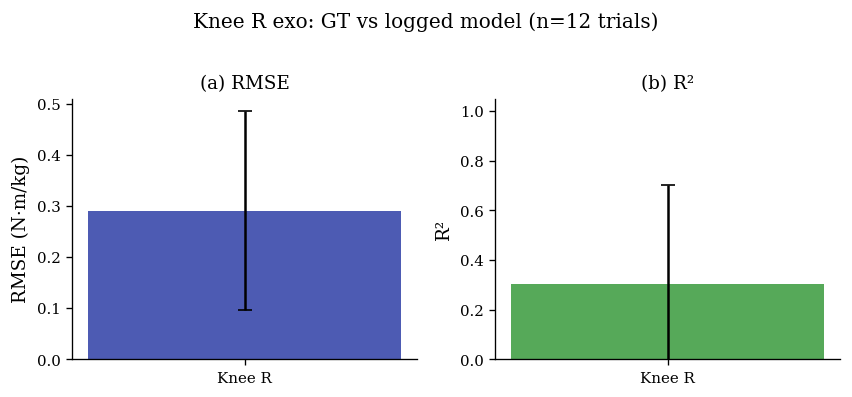

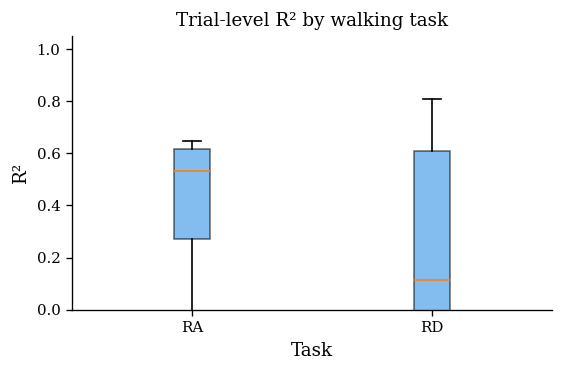

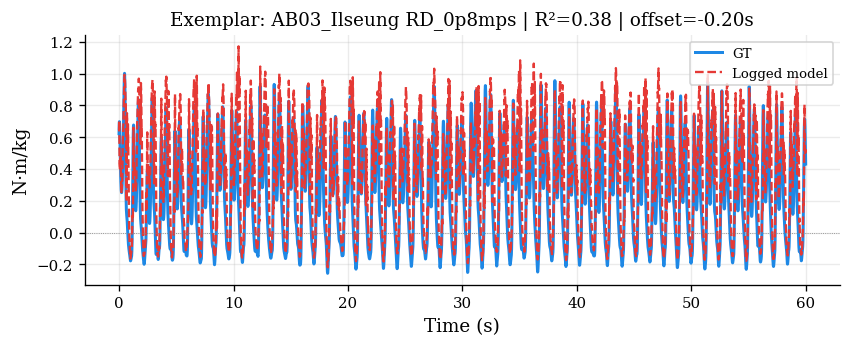


Saved files:
  fig1_summary.pdf
  fig1_summary.png
  fig2_r2_by_task.pdf
  fig2_r2_by_task.png
  fig3_exemplar_timeseries.pdf
  fig3_exemplar_timeseries.png
  table1_summary.csv
  table1_summary.tex
  table2_per_trial.csv
  table2_per_trial.tex
  table3_overall.csv
  table3_overall.tex


In [35]:
if not TRIAL_DATA:
    raise RuntimeError('No trials loaded.')

PAPER_EXCLUDE_SUBJECTS = {'AB02_Oscar'}
PAPER_EXCLUDE_TRIALS = {'AB05_Maria::LG_0p8mps'}
OUT_DIR = PROJECT_ROOT / 'analysis' / 'paper_outputs' / PAPER_SUBDIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

PAPER_RC = {
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
}
PALETTE = {'GT': '#1e88e5', 'Model': '#e53935', 'RMSE': '#3949ab', 'R2': '#43a047'}
TASK_ORDER = ['LG', 'RA', 'RD']


def _paper_exclude(trial_key: str) -> bool:
    subject = trial_key.split('::', 1)[0]
    if EXCLUDE_SUBJECTS is not None and subject in EXCLUDE_SUBJECTS:
        return True
    return subject in PAPER_EXCLUDE_SUBJECTS or trial_key in PAPER_EXCLUDE_TRIALS


def _mean_std(series, decimals=3):
    x = np.asarray(series, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return '—'
    return f'{np.mean(x):.{decimals}f} ± {np.std(x, ddof=1):.{decimals}f}'


def _save_table(df, stem, caption=''):
    csv_path = OUT_DIR / f'{stem}.csv'
    tex_path = OUT_DIR / f'{stem}.tex'
    df.to_csv(csv_path, index=False)
    tex = df.to_latex(index=False, escape=True, caption=caption, label=f'tab:{stem}')
    tex_path.write_text(tex)
    return csv_path, tex_path


def _trial_metrics_row(stem: str, wave: Dict) -> Dict:
    meta = trial_meta_from_stem(stem)
    m = analysis_trim_mask(wave['t'])
    rmse, r2 = rmse_r2(wave['gt_nmpkg'][m], wave['model_out_nmpkg_raw'][m])
    return {
        'trial': stem,
        'trial_key': meta['trial_key'],
        'subject': meta['subject'],
        'condition': meta['condition'],
        'task': meta['task'],
        'speed_mps': meta['speed_mps'],
        'joint': wave['joint'],
        'n_samples': int(m.sum()),
        'rmse_nmpkg': rmse,
        'r2_nmpkg': r2,
        'offset_s': wave['offset_s'],
        'mass_kg': wave['mass_kg'],
        'applied_key': wave['applied_key'],
        'model_out_key': wave['model_out_key'],
    }


metrics_rows = [_trial_metrics_row(stem, wave) for stem, wave in sorted(TRIAL_DATA.items())]
metrics_df = pd.DataFrame(metrics_rows)
metrics_df_paper = metrics_df[~metrics_df['trial_key'].map(_paper_exclude)].copy()

table_summary = pd.DataFrame([{
    'joint': JOINT_LABEL,
    'n_trials': metrics_df_paper['trial'].nunique(),
    'rmse_nmpkg_mean_std': _mean_std(metrics_df_paper['rmse_nmpkg']),
    'r2_nmpkg_mean_std': _mean_std(metrics_df_paper['r2_nmpkg']),
    'rmse_nmpkg_mean': float(metrics_df_paper['rmse_nmpkg'].mean()),
    'rmse_nmpkg_std': float(metrics_df_paper['rmse_nmpkg'].std(ddof=1)),
    'r2_nmpkg_mean': float(metrics_df_paper['r2_nmpkg'].mean()),
    'r2_nmpkg_std': float(metrics_df_paper['r2_nmpkg'].std(ddof=1)),
}])

table_per_trial = metrics_df_paper[[
    'subject', 'condition', 'task', 'speed_mps', 'n_samples',
    'rmse_nmpkg', 'r2_nmpkg', 'offset_s', 'mass_kg',
]].sort_values(['subject', 'task', 'speed_mps']).round(4)

table_overall = pd.DataFrame([{
    'metric': GT_METRIC_LABEL,
    'unit': 'N·m/kg / R²',
    'rmse_mean_std': _mean_std(metrics_df_paper['rmse_nmpkg']),
    'r2_mean_std': _mean_std(metrics_df_paper['r2_nmpkg']),
    'n_trials': len(metrics_df_paper),
}])

for stem, df, cap in [
    ('table1_summary', table_summary, f'{JOINT_LABEL} exo GT vs logged model (GPIO sync, {TRIM_START_SEC:.0f}s start + {TRIM_END_SEC:.0f}s end trim).'),
    ('table2_per_trial', table_per_trial, 'Per-trial metrics.'),
    ('table3_overall', table_overall, 'Overall summary across paper trials.'),
]:
    _save_table(df, stem, caption=cap)

print(f'Paper outputs → {OUT_DIR}')
print(f'  Sync: gpio_falling_edge | trim: {TRIM_START_SEC:.0f}s start + {TRIM_END_SEC:.0f}s end | trials: {len(metrics_df_paper)}')
display(table_summary)
display(table_per_trial.head(12))

task_order = [t for t in TASK_ORDER if t in metrics_df_paper['task'].unique()]
with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
    axes[0].bar([0], [table_summary['rmse_nmpkg_mean'].iloc[0]],
                yerr=[table_summary['rmse_nmpkg_std'].iloc[0]],
                color=PALETTE['RMSE'], capsize=4, alpha=0.9, width=0.55)
    axes[0].set_xticks([0]); axes[0].set_xticklabels([JOINT_LABEL])
    axes[0].set_ylabel('RMSE (N·m/kg)'); axes[0].set_title('(a) RMSE')
    axes[1].bar([0], [table_summary['r2_nmpkg_mean'].iloc[0]],
                yerr=[table_summary['r2_nmpkg_std'].iloc[0]],
                color=PALETTE['R2'], capsize=4, alpha=0.9, width=0.55)
    axes[1].set_xticks([0]); axes[1].set_xticklabels([JOINT_LABEL])
    axes[1].set_ylabel('R²'); axes[1].set_ylim(0, 1.05); axes[1].set_title('(b) R²')
    fig.suptitle(f'{JOINT_LABEL} exo: GT vs logged model (n={len(metrics_df_paper)} trials)', y=1.02, fontsize=12)
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'fig1_summary.{ext}')
    plt.show()

    if len(task_order) >= 2:
        groups = [metrics_df_paper.loc[metrics_df_paper['task'] == t, 'r2_nmpkg'].to_numpy() for t in task_order]
        fig, ax = plt.subplots(figsize=(4.8, 3.2))
        bp = ax.boxplot(groups, tick_labels=task_order, patch_artist=True)
        for box in bp['boxes']:
            box.set(facecolor=PALETTE['GT'], alpha=0.55)
        ax.set_ylabel('R²'); ax.set_xlabel('Task')
        ax.set_title('Trial-level R² by walking task')
        ax.set_ylim(0, 1.05)
        fig.tight_layout()
        for ext in ('pdf', 'png'):
            fig.savefig(OUT_DIR / f'fig2_r2_by_task.{ext}')
        plt.show()

    ex_idx = (metrics_df_paper['r2_nmpkg'] - metrics_df_paper['r2_nmpkg'].median()).abs().argsort().iloc[0]
    ex_stem = metrics_df_paper.iloc[ex_idx]['trial']
    ex_row = metrics_df_paper.iloc[ex_idx]
    wave = TRIAL_DATA[ex_stem]
    m = analysis_trim_mask(wave['t'])
    t = wave['t'][m] - np.nanmin(wave['t'][m])
    gt = wave['gt_nmpkg'][m]
    model = wave['model_out_nmpkg_raw'][m]
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(t, gt, color=PALETTE['GT'], lw=1.8, label='GT')
    ax.plot(t, model, color=PALETTE['Model'], lw=1.4, ls='--', label='Logged model')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('N·m/kg')
    ax.set_title(
        f'Exemplar: {ex_row["subject"]} {ex_row["condition"]} | '
        f'R²={ex_row["r2_nmpkg"]:.2f} | offset={ex_row["offset_s"]:+.2f}s'
    )
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'fig3_exemplar_timeseries.{ext}')
    plt.show()

print('\nSaved files:')
for p in sorted(OUT_DIR.glob('*')):
    print(f'  {p.name}')
